# Final Model Comparison

This notebook summarizes the final performance of all four AI-text detection models:

- TF-IDF + Logistic Regression
- TF-IDF + SVM
- RoBERTa-base
- DeBERTa-base

The models are compared on:

1. Original in-distribution test data
2. External HC3 cross-dataset evaluation
3. Generalization performance
4. Efficiency and deployment considerations

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
results_df = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Original Accuracy": 0.994992,
        "Original Precision": 0.993312,
        "Original Recall": 0.993239,
        "Original F1": 0.993275,
        "Original ROC-AUC": 0.999743,

        "HC3 Accuracy": 0.469753,
        "HC3 Precision": 0.378184,
        "HC3 Recall": 0.935683,
        "HC3 F1": 0.538655,
        "HC3 ROC-AUC": 0.758304
    },

    {
        "Model": "SVM",
        "Original Accuracy": 0.999371,
        "Original Precision": 0.999192,
        "Original Recall": 0.999118,
        "Original F1": 0.999155,
        "Original ROC-AUC": 0.999994,

        "HC3 Accuracy": 0.561785,
        "HC3 Precision": 0.422031,
        "HC3 Recall": 0.878491,
        "HC3 F1": 0.570157,
        "HC3 ROC-AUC": 0.764126
    },

    {
        "Model": "RoBERTa",
        "Original Accuracy": 0.998987,
        "Original Precision": 0.997653,
        "Original Recall": 0.999633,
        "Original F1": 0.998642,
        "Original ROC-AUC": 0.999951,

        "HC3 Accuracy": 0.490098,
        "HC3 Precision": 0.393448,
        "HC3 Recall": 0.999352,
        "HC3 F1": 0.564608,
        "HC3 ROC-AUC": 0.845700
    },

    {
        "Model": "DeBERTa",
        "Original Accuracy": 0.996087,
        "Original Precision": 0.991243,
        "Original Recall": 0.998310,
        "Original F1": 0.994764,
        "Original ROC-AUC": 0.999901,

        "HC3 Accuracy": 0.498594,
        "HC3 Precision": 0.397516,
        "HC3 Recall": 0.999996,
        "HC3 F1": 0.568831,
        "HC3 ROC-AUC": 0.979550
    }
])

results_df

,Model,Original Accuracy,Original Precision,Original Recall,Original F1,Original ROC-AUC,HC3 Accuracy,HC3 Precision,HC3 Recall,HC3 F1,HC3 ROC-AUC
0,Logistic Regression,0.994992,0.993312,0.993239,0.993275,0.999743,0.469753,0.378184,0.935683,0.538655,0.758304
1,SVM,0.999371,0.999192,0.999118,0.999155,0.999994,0.561785,0.422031,0.878491,0.570157,0.764126
2,RoBERTa,0.998987,0.997653,0.999633,0.998642,0.999951,0.490098,0.393448,0.999352,0.564608,0.845700
3,DeBERTa,0.996087,0.991243,0.998310,0.994764,0.999901,0.498594,0.397516,0.999996,0.568831,0.979550


In [3]:
results_df["Absolute F1 Drop"] = (
    results_df["Original F1"]
    - results_df["HC3 F1"]
)

results_df["Relative F1 Drop (%)"] = (
    results_df["Absolute F1 Drop"]
    / results_df["Original F1"]
) * 100

results_df[
    [
        "Model",
        "Original F1",
        "HC3 F1",
        "Absolute F1 Drop",
        "Relative F1 Drop (%)"
    ]
]

,Model,Original F1,HC3 F1,Absolute F1 Drop,Relative F1 Drop (%)
0,Logistic Regression,0.993275,0.538655,0.454620,45.769802
1,SVM,0.999155,0.570157,0.428998,42.936081
2,RoBERTa,0.998642,0.564608,0.434034,43.462422
3,DeBERTa,0.994764,0.568831,0.425933,42.817492


In [4]:
presentation_table = results_df[
    [
        "Model",
        "Original Accuracy",
        "Original Precision",
        "Original Recall",
        "Original F1",
        "Original ROC-AUC",
        "HC3 Accuracy",
        "HC3 Precision",
        "HC3 Recall",
        "HC3 F1",
        "HC3 ROC-AUC"
    ]
].copy()

numeric_cols = presentation_table.columns.drop("Model")

presentation_table[numeric_cols] = (
    presentation_table[numeric_cols] * 100
).round(2)

presentation_table

,Model,Original Accuracy,Original Precision,Original Recall,Original F1,Original ROC-AUC,HC3 Accuracy,HC3 Precision,HC3 Recall,HC3 F1,HC3 ROC-AUC
0,Logistic Regression,99.50,99.33,99.32,99.33,99.97,46.98,37.82,93.57,53.87,75.83
1,SVM,99.94,99.92,99.91,99.92,100.00,56.18,42.20,87.85,57.02,76.41
2,RoBERTa,99.90,99.77,99.96,99.86,100.00,49.01,39.34,99.94,56.46,84.57
3,DeBERTa,99.61,99.12,99.83,99.48,99.99,49.86,39.75,100.00,56.88,97.96


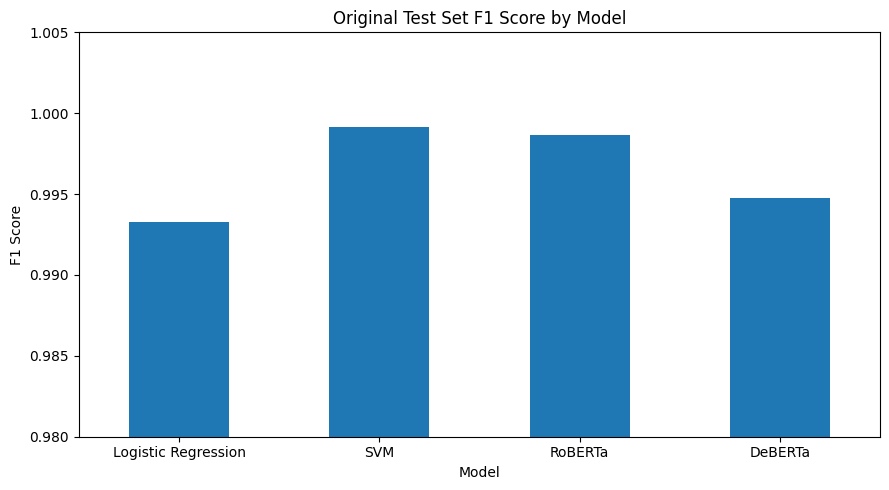

In [5]:
original_f1 = results_df.set_index("Model")[
    "Original F1"
]

original_f1.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Original Test Set F1 Score by Model")
plt.ylabel("F1 Score")
plt.xlabel("Model")
plt.ylim(0.98, 1.005)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

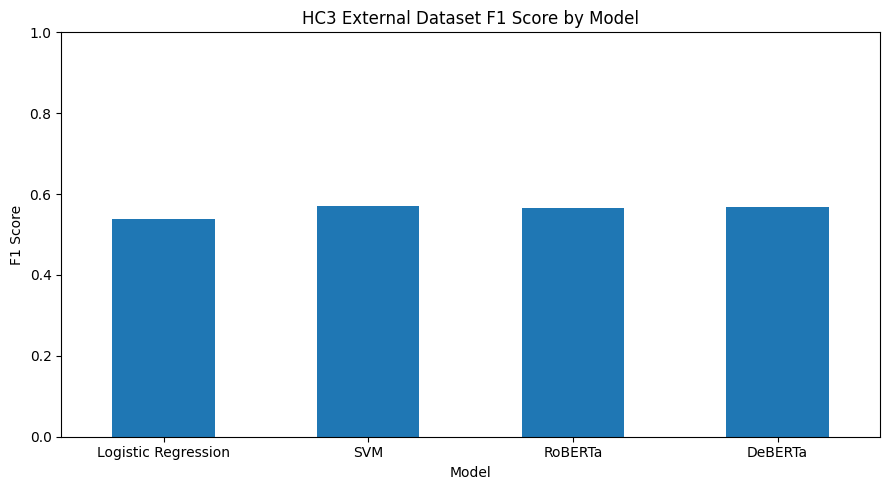

In [6]:
hc3_f1 = results_df.set_index("Model")[
    "HC3 F1"
]

hc3_f1.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("HC3 External Dataset F1 Score by Model")
plt.ylabel("F1 Score")
plt.xlabel("Model")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

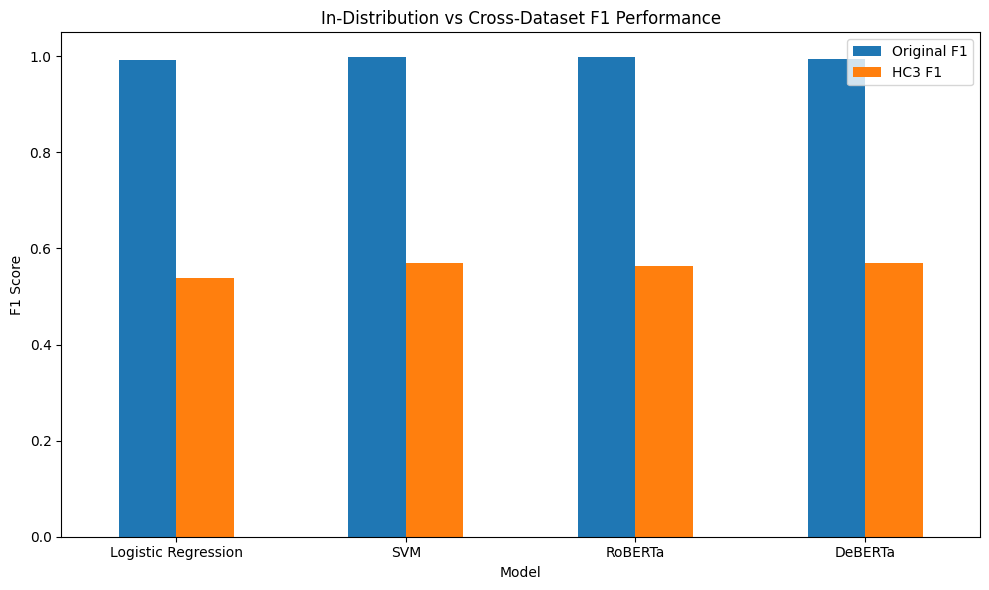

In [7]:
comparison_plot = results_df.set_index("Model")[
    [
        "Original F1",
        "HC3 F1"
    ]
]

comparison_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title(
    "In-Distribution vs Cross-Dataset F1 Performance"
)

plt.ylabel("F1 Score")
plt.xlabel("Model")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

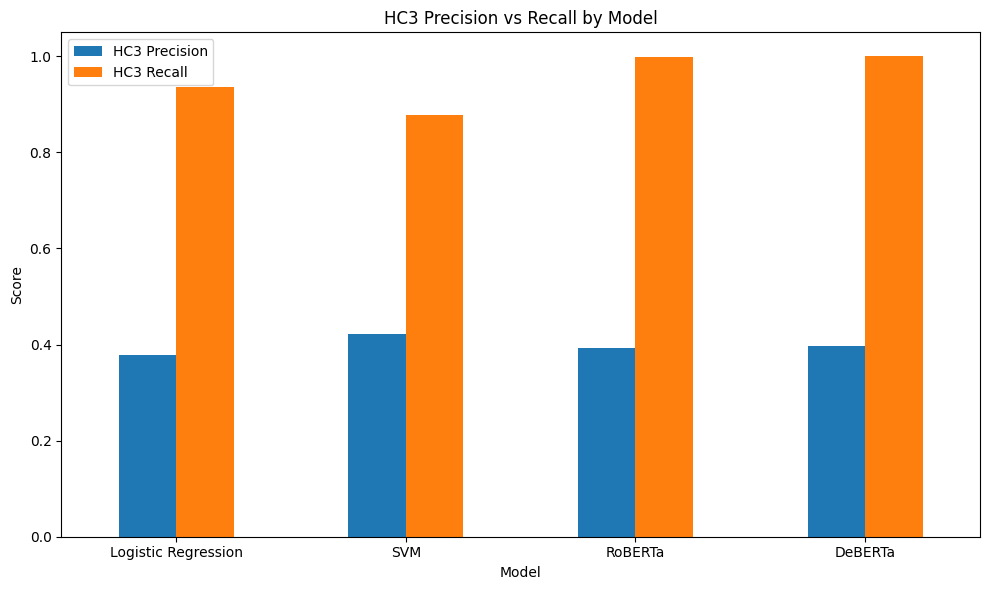

In [8]:
precision_recall_plot = results_df.set_index(
    "Model"
)[
    [
        "HC3 Precision",
        "HC3 Recall"
    ]
]

precision_recall_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title(
    "HC3 Precision vs Recall by Model"
)

plt.ylabel("Score")
plt.xlabel("Model")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

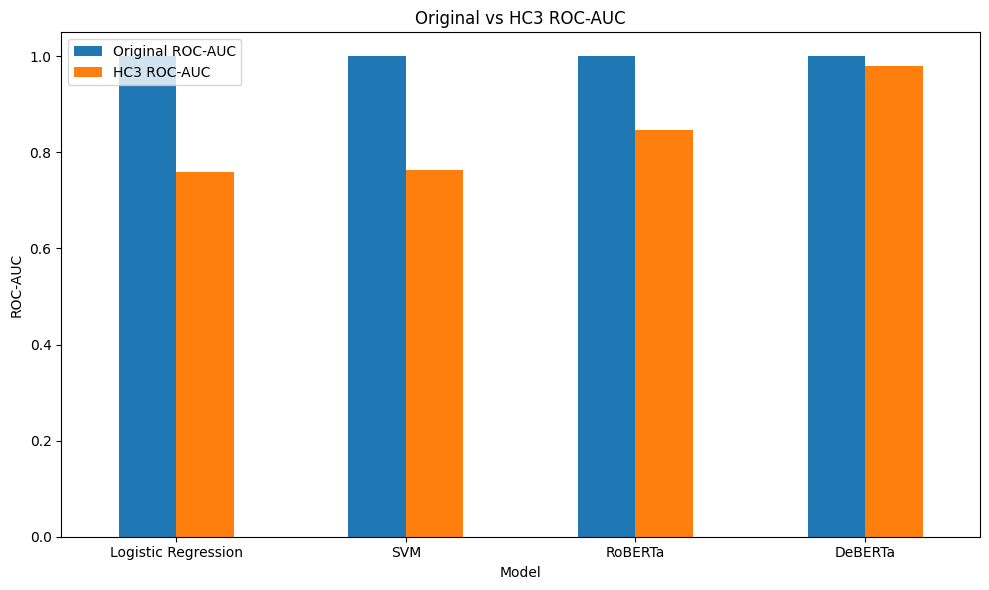

In [9]:
roc_comparison = results_df.set_index(
    "Model"
)[
    [
        "Original ROC-AUC",
        "HC3 ROC-AUC"
    ]
]

roc_comparison.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title(
    "Original vs HC3 ROC-AUC"
)

plt.ylabel("ROC-AUC")
plt.xlabel("Model")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

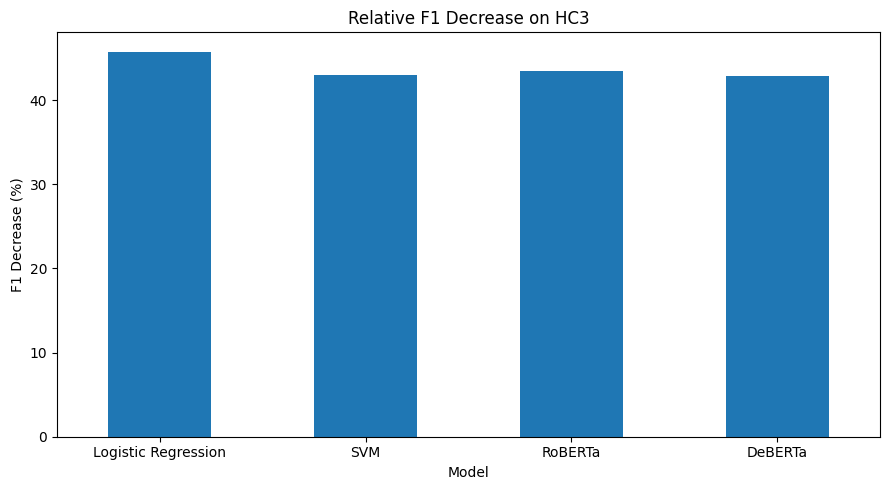

In [10]:
drop_plot = results_df.set_index(
    "Model"
)[
    "Relative F1 Drop (%)"
]

drop_plot.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title(
    "Relative F1 Decrease on HC3"
)

plt.ylabel("F1 Decrease (%)")
plt.xlabel("Model")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [11]:
deployment_df = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Model Type": "Traditional ML",
        "Hardware": "CPU",
        "Original F1": 0.993275,
        "HC3 F1": 0.538655,
        "Deployment Complexity": "Low",
        "Public Deployment": "Not selected"
    },

    {
        "Model": "SVM",
        "Model Type": "Traditional ML",
        "Hardware": "CPU",
        "Original F1": 0.999155,
        "HC3 F1": 0.570157,
        "Deployment Complexity": "Low",
        "Public Deployment": "Selected"
    },

    {
        "Model": "RoBERTa",
        "Model Type": "Transformer",
        "Hardware": "GPU training / CPU inference possible",
        "Original F1": 0.998642,
        "HC3 F1": 0.564608,
        "Deployment Complexity": "High",
        "Public Deployment": "Local demo / HF Hub"
    },

    {
        "Model": "DeBERTa",
        "Model Type": "Transformer",
        "Hardware": "GPU training",
        "Original F1": 0.994764,
        "HC3 F1": 0.568831,
        "Deployment Complexity": "High",
        "Public Deployment": "Not selected"
    }
])

deployment_df

,Model,Model Type,Hardware,Original F1,HC3 F1,Deployment Complexity,Public Deployment
0,Logistic Regression,Traditional ML,CPU,0.993275,0.538655,Low,Not selected
1,SVM,Traditional ML,CPU,0.999155,0.570157,Low,Selected
2,RoBERTa,Transformer,GPU training / CPU inference possible,0.998642,0.564608,High,Local demo / HF Hub
3,DeBERTa,Transformer,GPU training,0.994764,0.568831,High,Not selected


In [12]:
results_df[
    [
        "Model",
        "Original F1"
    ]
].sort_values(
    "Original F1",
    ascending=False
)

,Model,Original F1
1,SVM,0.999155
2,RoBERTa,0.998642
3,DeBERTa,0.994764
0,Logistic Regression,0.993275


In [13]:
results_df[
    [
        "Model",
        "HC3 F1"
    ]
].sort_values(
    "HC3 F1",
    ascending=False
)

,Model,HC3 F1
1,SVM,0.570157
3,DeBERTa,0.568831
2,RoBERTa,0.564608
0,Logistic Regression,0.538655


In [14]:
results_df[
    [
        "Model",
        "HC3 ROC-AUC"
    ]
].sort_values(
    "HC3 ROC-AUC",
    ascending=False
)

,Model,HC3 ROC-AUC
3,DeBERTa,0.979550
2,RoBERTa,0.845700
1,SVM,0.764126
0,Logistic Regression,0.758304


In [15]:
from pathlib import Path

OUTPUT_DIR = Path("../outputs")

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

results_path = (
    OUTPUT_DIR
    / "final_model_comparison.csv"
)

results_df.to_csv(
    results_path,
    index=False
)

print("Saved to:")
print(results_path)

Saved to:
..\outputs\final_model_comparison.csv


## Final Model Selection and Conclusion

All four models achieved near-perfect performance on the original test dataset. However, when evaluated on the independent HC3 dataset without retraining, performance decreased substantially across all architectures.

TF-IDF + SVM achieved the highest F1 score on both the original test set and the HC3 external dataset. It also required substantially fewer computational resources than the transformer models, making it the most practical choice for public deployment.

RoBERTa and DeBERTa demonstrated stronger external ranking performance through ROC-AUC, particularly DeBERTa. However, both transformer models showed very high recall combined with low precision on HC3, indicating a tendency to classify human-written text as AI-generated.

Based on predictive performance, generalization, inference efficiency, memory requirements, and deployment constraints, TF-IDF + SVM was selected as the deployed model.

RoBERTa remains the primary transformer experiment and is hosted on Hugging Face Model Hub. A local RoBERTa application was also implemented successfully, while public transformer deployment was limited by free-tier hosting memory constraints.

The results demonstrate that strong in-distribution performance alone is not sufficient evidence of robust AI-text detection. Cross-dataset evaluation revealed substantial generalization limitations and highlights the need for diverse training data, calibration, and external validation before AI-text detectors are used in high-stakes settings.